# Measuring Cosine Distance of Section Representations

### import libraries

In [1]:
from wb0configs import configs
from wb0configs.helpers import store_file, load_file
from wb4task.task_construction.section.construct_entity_sec import get_most_frequent

config = configs.ConfigBase()

In [2]:
# pytorch mlp for binary classification
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
import torch
import matplotlib.pylab as plt
import matplotlib as mpl
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from operator import itemgetter 
from matplotlib import pyplot
from collections import defaultdict, Counter
from operator import itemgetter 
from tqdm import tqdm
import statistics

### Dataloader

In [3]:
X_E, X_A = load_file(config.get_path("task") / "entity_sec" / "pre" / "sec_sec_emb_tfidf", ftype="pkl")
sec_sec_E, sec_sec_A = load_file(config.get_path("task") / "entity_sec" / "pre" / "sec_sec_counts_tfidf", ftype="pkl")
X_E, X_A = get_most_frequent(X_E, X_A, sec_sec_E, sec_sec_A, k=1000)

get_most_frequent


## Measure Pairwise Section-Section Cosine Distance

In [4]:
def compute_sec_sec_dist(sec_sec_emb):
    count = 0
    
    cos = torch.nn.CosineSimilarity(dim=1, eps=1e-8)
    pdist = torch.nn.PairwiseDistance(p=2.0, eps=1e-06, keepdim=False)
    
    sec_sec_name = list(sec_sec_emb.keys())
    sec_sec_mean = list()
    sec_sec_std = list()
    
    for emb_list in tqdm(list(sec_sec_emb.values())):

        sec_sec_dis = torch.FloatTensor(len(emb_list),1) ## similariy per section-section pair
        for j, (emb1, emb2) in enumerate(emb_list):
            
            #dist_value = pdist(emb1.view(1,-1), emb2.view(1,-1))
            dist_value = 1 - cos(emb1.view(1,-1), emb2.view(1,-1))
            sec_sec_dis[j] = dist_value.float()

        ## mean and variance
        sec_sec_mean.append(float(torch.mean(sec_sec_dis, axis = 0)))
        sec_sec_std.append(float(torch.std(sec_sec_dis, unbiased=True)))
        
    return sec_sec_name, sec_sec_mean, sec_sec_std

e_name, e_mean, e_std = compute_sec_sec_dist(X_E)
a_name, a_mean, a_std = compute_sec_sec_dist(X_A)

print("allies", "min dist:", min(a_mean), "max dist:", max(a_mean))
print("enemies", "min dist:", min(e_mean), "max dist:", max(e_mean))

100%|██████████| 1000/1000 [01:33<00:00, 10.66it/s]

allies min dist: 0.23668654263019562 max dist: 0.9945107102394104
enemies min dist: 0.2504707872867584 max dist: 0.9986796975135803


### Sorting by Mean

In [5]:
from_top_k = 0
to_top_k = 1000
e_mean_sorted_ind, e_mean_sorted  = zip(*sorted(enumerate(e_mean), key=itemgetter(1), reverse=False))
e_mean_sorted_ind, e_mean_sorted  = e_mean_sorted_ind[from_top_k:to_top_k], e_mean_sorted[from_top_k:to_top_k]
e_name_sorted = itemgetter(*e_mean_sorted_ind)(e_name)
e_std_sorted = itemgetter(*e_mean_sorted_ind)(e_std)

In [6]:
a_mean_sorted_ind, a_mean_sorted  = zip(*sorted(enumerate(a_mean), key=itemgetter(1), reverse=False))
a_mean_sorted_ind, a_mean_sorted  = a_mean_sorted_ind[from_top_k:to_top_k], a_mean_sorted[from_top_k:to_top_k]
a_name_sorted = itemgetter(*a_mean_sorted_ind)(a_name)
a_std_sorted = itemgetter(*a_mean_sorted_ind)(a_std)

### Visualization

<ipython-input-7-3d1ef7ae9475>:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(E_sec_sec, rotation=30, fontsize = 8, color = "red", ha="right")
<ipython-input-7-3d1ef7ae9475>:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(A_sec_sec, rotation=30, fontsize = 8, color = "green", ha="right")


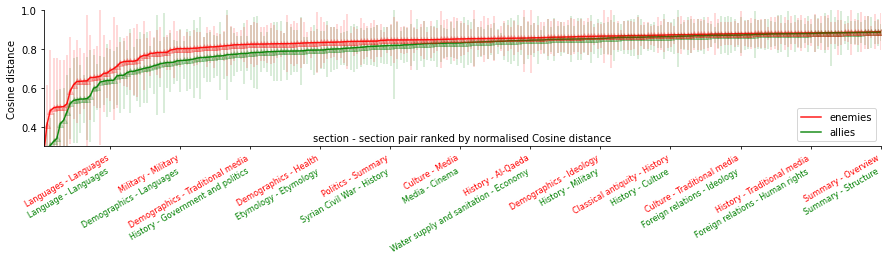

In [7]:
bins = np.linspace(0, len(e_mean_sorted), len(a_mean_sorted))

fig, ax = plt.subplots(figsize=(15,2.5))
e_line, = ax.plot(bins, e_mean_sorted, color = "r", alpha = 0.9, label = "enemies")
a_line, = ax.plot(bins, a_mean_sorted, color = "g", alpha = 0.9, label = "allies")
ax.errorbar(bins, a_mean_sorted, a_std_sorted, linestyle='None', marker='^', color = "g", alpha = 0.2)
ax.errorbar(bins, e_mean_sorted, e_std_sorted, linestyle='None', marker='^', color = "r", alpha = 0.2)

ax.set_ylabel("Cosine distance")
ax.set_xlabel("section - section pair ranked by normalised Cosine distance",  labelpad=-96)

every_nth = 21

A_sec_sec = list(a_name_sorted[0::every_nth])
E_sec_sec = list(e_name_sorted[0::every_nth])

ax.set_xticklabels(E_sec_sec, rotation=30, fontsize = 8, color = "red", ha="right")
ax.xaxis.set_ticks(np.arange(20, max(bins), every_nth))
ax.tick_params(axis=u'both', which=u'both',length=3)

# Move twinned axis ticks and label from top to bottom
ax2 = ax.twiny()
ax2.xaxis.set_ticks_position("bottom")
ax2.xaxis.set_label_position("bottom")
ax2.patch.set_visible(False)
ax2.set_frame_on(False)
ax2.spines["bottom"].set_position(("axes", -0.12))
ax2.set_xticklabels(A_sec_sec, rotation=30, fontsize = 8, color = "green", ha="right")
ax2.xaxis.set_ticks(np.arange(20, max(bins), every_nth))
ax2.tick_params(axis=u'both', which=u'both',length=0)

# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlim(0, 251)#max(bins))
ax2.set_xlim(0, 251)#max(bins))
ax.set_ylim(0.3, 1.0)

## legend
ax.legend(handles=[e_line, a_line], loc = 'lower right')#, bbox_to_anchor=(1,0.75))

# Analysis

### Allies versus Enemies Mean Section Distance

In [8]:
print("allies mean", statistics.mean(a_mean))
print("allies std", statistics.mean(a_std))
print("enemies mean", statistics.mean(e_mean))
print("enemies std", statistics.mean(e_std))

allies mean 0.9050744194835424
allies std 0.06379371071793138
enemies mean 0.912623006016016
enemies std 0.0603269532546401


### Section-Section Pair Comparison

In [9]:
section_title = "History - History"
print(section_title)
print("allies:", a_mean[a_name.index(section_title)])
print("enemies:", e_mean[e_name.index(section_title)])

section_title = "Summary - Summary"
print(section_title)
print("allies:", a_mean[a_name.index(section_title)])
print("enemies:", e_mean[e_name.index(section_title)])

section_title = "Military - Military"
print(section_title)
print("allies:", a_mean[a_name.index(section_title)])
print("enemies:", e_mean[e_name.index(section_title)])

section_title = "Education - Education"
print(section_title)
print("allies:", a_mean[a_name.index(section_title)])
print("enemies:", e_mean[e_name.index(section_title)])

History - History
allies: 0.6652213335037231
enemies: 0.7423944473266602
Summary - Summary
allies: 0.7910503149032593
enemies: 0.8478352427482605
Military - Military
allies: 0.6856045722961426
enemies: 0.6995295286178589
Education - Education
allies: 0.4164486527442932
enemies: 0.5020043253898621
